# Lecture 16 — Diffusion Models (DDPM)

**PHYG004 / PHY5006, 2026 Spring · Sogang University**
Prof. Young Woo Choi

---

## What you'll learn today

By the end of this notebook you will be able to:

1. Explain in plain words what a **diffusion model** is and why "destroy, then learn to rebuild" works.
2. **Derive the forward (noising) process** and prove the closed-form identity that lets us jump $T$ steps in one line.
3. **Derive the training loss** (ε-prediction MSE) from the variational lower bound — without hand-waving.
4. Build a small DDPM in JAX (~50 lines of code) and train it on two-dimensional toy data.
5. Run the **reverse-time sampler** (DDPM Algorithm 2) and watch noise turn into structured data, step by step.
6. Apply the same DDPM to **a Boltzmann distribution** and to **handwritten digits**.
7. Connect ε-prediction to the **score function** $\nabla\!\log p$ and see why diffusion models are continuous-time normalizing flows in disguise.

> **Runtime tip.** Everything runs on the free Colab CPU in 5–10 minutes. No GPU needed.

> **What you should already know.** From earlier lectures: how to train a small neural network in JAX with `flax.nnx`, what a probability density is, what a Gaussian is, and the change-of-variables story from Lecture 15. We will use a couple of Gaussian identities; you don't need to remember them, we'll re-derive what we need.

<!-- lecture16-visual:start:title-diffusion -->
<!-- lecture16-visual:end:title-diffusion -->


## 0. Setup

In [ ]:
# !pip install -q jax jaxlib optax flax matplotlib

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import flax.nnx as nnx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from functools import partial

print(f"JAX backend: {jax.default_backend()}")


## 1. The problem in one sentence

> *Given a bunch of data points $x_1, x_2, \ldots, x_N$, learn how to make **new ones** that look just like them.*

Same setup as Lectures 14 (VAE) and 15 (Flows). We want a probability density $p_\theta(x)$ such that

$$
p_\theta(x) \;\approx\; p_{\text{data}}(x),
$$

so we can both **sample** new data and (ideally) **evaluate** the density of a given point.

### Where diffusion sits next to VAE / Flow / GAN

| | **VAE** (L14) | **GAN** | **Flow** (L15) | **Diffusion** (today) |
|---|---|---|---|---|
| Sampling cost | 1 forward pass | 1 forward pass | 1 forward pass | $T$ forward passes ($T$ ~ 50–1000) |
| Density $p_\theta(x)$ | ELBO (lower bound) | not available | **exact** | ELBO; can be made exact in continuous time |
| Training signal | reconstruction + KL | adversarial | maximum likelihood | denoising MSE — a single scalar loss |
| Architecture constraint | encoder + decoder | unconstrained | invertible (Jacobian) | unconstrained (just a regressor!) |
| Image quality at scale | OK | great until ~2022 | competitive | **SOTA in 2026** |

**The deal.** Diffusion gives up the "one-shot sample" speed of flows and GANs in exchange for a much easier training problem: the network just learns to **denoise**, which is an ordinary regression task. No invertibility, no adversary, no encoder/decoder pair to balance. That tradeoff turned out to be the right one for high-dimensional data — virtually all of today's image, video, audio, and protein-structure generative models are diffusion (or close relatives).

We will see how the magic works and code one up by hand.


## 2. The big idea — destroy, then learn to rebuild

Take any data point $x_0$ (a photo, a 2D coordinate, anything). Add a tiny bit of Gaussian noise. Add a tiny bit more. Repeat for $T$ steps. Eventually the data is gone and you have **pure noise** $x_T \sim \mathcal{N}(0, I)$.

That is the **forward process** (red arrows in the picture below). It is hand-coded, deterministic in design, and contains zero learnable parameters.

Now imagine the picture flipped. Instead of pushing $x_0$ toward noise, we **start from** $x_T \sim \mathcal{N}(0, I)$ and **undo each tiny step** — going from "a-bit-noisy" back to "a-bit-less-noisy" — until we land on a fresh data point $x_0$.

That backwards arrow (blue) is the **reverse process**. It is exactly what we will train a neural network to do.


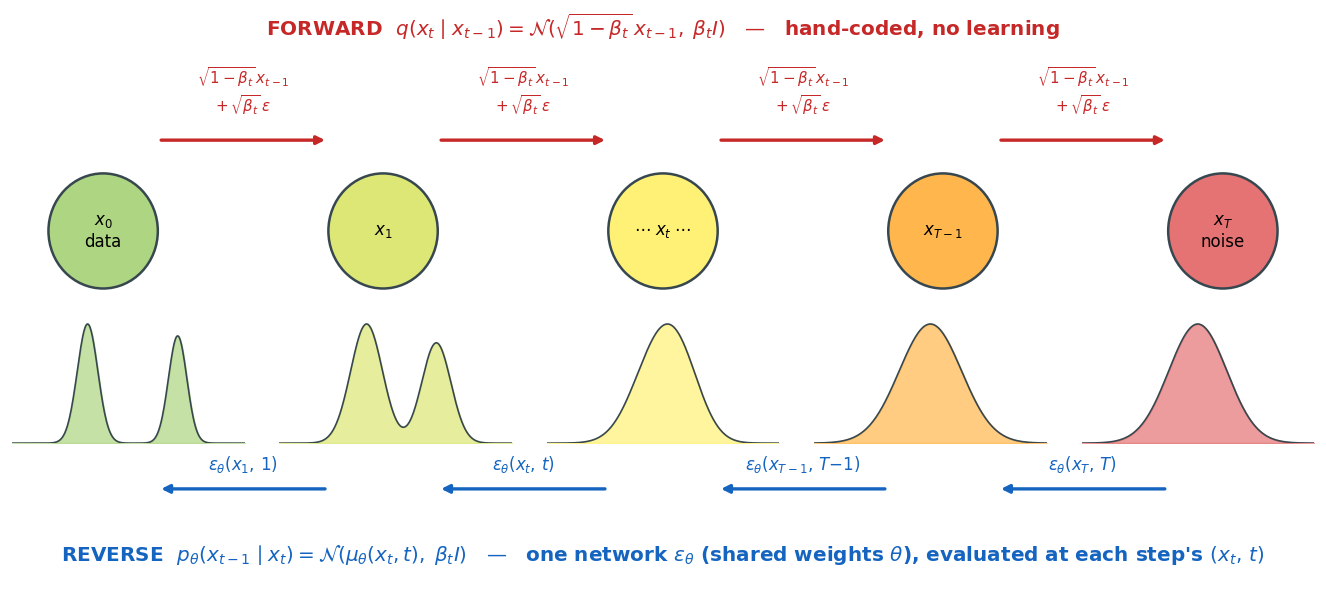

In [ ]:
# A schematic of the diffusion process: forward (red, top) and reverse (blue, bottom),
# with a sketch of the marginal density at each step.
fig = plt.figure(figsize=(14, 6.0))
gs = fig.add_gridspec(4, 5, height_ratios=[0.95, 1.0, 1.0, 0.95], hspace=0.05, wspace=0.15)

nodes_x = np.linspace(0.7, 9.3, 5)
labels  = [r"$x_0$" + "\ndata", r"$x_1$", r"$\cdots\;x_t\;\cdots$", r"$x_{T-1}$", r"$x_T$" + "\nnoise"]
colors  = ["#aed581", "#dce775", "#fff176", "#ffb74d", "#e57373"]

# Top: title (top), two-line arrow label (middle), arrow (bottom)
ax_fw = fig.add_subplot(gs[0, :]); ax_fw.axis("off")
ax_fw.set_xlim(0, 10); ax_fw.set_ylim(0, 1)
ax_fw.text(5.0, 0.92,
           r"FORWARD  $q(x_t \mid x_{t-1}) = \mathcal{N}(\sqrt{1-\beta_t}\,x_{t-1},\; \beta_t I)$  "
           r"$\;$—$\;$  hand-coded, no learning",
           ha="center", fontsize=12, color="#c62828", fontweight="bold")
for i in range(4):
    x1, x2 = nodes_x[i] + 0.42, nodes_x[i+1] - 0.42
    ax_fw.annotate("", xy=(x2, 0.12), xytext=(x1, 0.12),
                   arrowprops=dict(arrowstyle="-|>", color="#c62828", lw=2.0))
    ax_fw.text((x1+x2)/2, 0.5,
               r"$\sqrt{1-\beta_t}\,x_{t-1}$" + "\n" + r"$+\,\sqrt{\beta_t}\,\varepsilon$",
               ha="center", va="center", fontsize=9, color="#c62828")

# Middle row: nodes
ax_node = fig.add_subplot(gs[1, :]); ax_node.axis("off")
ax_node.set_xlim(0, 10); ax_node.set_ylim(0, 1)
for cx, lbl, col in zip(nodes_x, labels, colors):
    ax_node.add_patch(plt.Circle((cx, 0.5), 0.42, color=col, ec="#37474f", lw=1.5, zorder=3))
    ax_node.text(cx, 0.5, lbl, ha="center", va="center", fontsize=10, zorder=4)

# Density sketches under each node (bimodal data dissolving into a single Gaussian)
xs = np.linspace(-4, 4, 400)
densities = [
    0.9 * np.exp(-(xs - 1.7)**2 / 0.20) + 1.0 * np.exp(-(xs + 1.4)**2 / 0.25),
    0.8 * np.exp(-(xs - 1.4)**2 / 0.50) + 0.95 * np.exp(-(xs + 1.0)**2 / 0.60),
    0.7 * np.exp(-(xs - 0.6)**2 / 1.10) + 0.85 * np.exp(-(xs + 0.3)**2 / 1.40),
    0.95 * np.exp(-xs**2 / 2.30),
    1.0 * np.exp(-xs**2 / 2.00),
]
for k, (d, col) in enumerate(zip(densities, colors)):
    ax = fig.add_subplot(gs[2, k])
    d_n = d / np.trapezoid(d, xs)
    ax.fill_between(xs, d_n, color=col, alpha=0.7)
    ax.plot(xs, d_n, color="#37474f", lw=1.0)
    ax.set_xlim(-4, 4); ax.set_ylim(0, max(d_n) * 1.15)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_frame_on(False)

# Bottom: reverse arrows + footer. Labels are per-step so it's visible that the SAME
# network ε_θ is called with a DIFFERENT (x, t) at every step (a common confusion).
ax_rv = fig.add_subplot(gs[3, :]); ax_rv.axis("off")
ax_rv.set_xlim(0, 10); ax_rv.set_ylim(0, 1)
reverse_labels = [
    r"$\varepsilon_\theta(x_1,\,1)$",
    r"$\varepsilon_\theta(x_t,\,t)$",
    r"$\varepsilon_\theta(x_{T-1},\,T{-}1)$",
    r"$\varepsilon_\theta(x_T,\,T)$",
]
for i, lbl in enumerate(reverse_labels):
    x1, x2 = nodes_x[i+1] - 0.42, nodes_x[i] + 0.42
    ax_rv.annotate("", xy=(x2, 0.7), xytext=(x1, 0.7),
                   arrowprops=dict(arrowstyle="-|>", color="#1565c0", lw=2.0))
    ax_rv.text((x1+x2)/2, 0.85, lbl, ha="center", fontsize=10, color="#1565c0")
ax_rv.text(5.0, 0.15,
           r"REVERSE  $p_\theta(x_{t-1} \mid x_t) = \mathcal{N}(\mu_\theta(x_t, t),\; \beta_t I)$  "
           r"$\;$—$\;$  one network $\varepsilon_\theta$ (shared weights $\theta$), evaluated at each step's $(x_t,\,t)$",
           ha="center", fontsize=12, color="#1565c0", fontweight="bold")

plt.show()


### Why is this any easier than just learning $p(x)$ directly?

Two reasons.

1. **Each tiny step is approximately a Gaussian.** If $\beta_t$ is small, the optimal $p(x_{t-1} \mid x_t)$ is itself a Gaussian with a known variance and a mean we just have to predict. A network learning a mean is just doing regression — no adversary, no Jacobian, no ELBO juggling.
2. **The endpoints are perfect.** $x_T$ is exactly Gaussian (we made it so). $x_0$ is real data. The hard problem of "learn an unknown density" is decomposed into many easy problems of "denoise one tiny step", each of which the network handles with garden-variety MSE.

Let's first watch the forward process actually happen.


In [ ]:
# A 2D dataset to play with: "two moons". We'll watch a clean swirl of points dissolve into Gaussian noise.
def make_moons(n, noise=0.06, key=jr.PRNGKey(0)):
    k1, k2, k3 = jr.split(key, 3)
    n_half = n // 2
    theta_u = jnp.linspace(0, jnp.pi, n_half)
    theta_l = jnp.linspace(0, jnp.pi, n - n_half)
    upper = jnp.stack([jnp.cos(theta_u), jnp.sin(theta_u)], axis=1)
    lower = jnp.stack([1 - jnp.cos(theta_l), 1 - jnp.sin(theta_l) - 0.5], axis=1)
    data = jnp.concatenate([upper, lower], axis=0) + noise * jr.normal(k2, (n, 2))
    return data[jr.permutation(k3, len(data))]


x0 = make_moons(2000, key=jr.PRNGKey(0))
print(f"x0 shape: {x0.shape}")

# Hand-pick a tiny schedule for visualization: T=100 small noise injections.
T_demo = 100
betas_demo = jnp.linspace(1e-4, 0.04, T_demo)

# Iteratively add noise step by step. Each step: x_t = sqrt(1-beta_t)*x_{t-1} + sqrt(beta_t)*epsilon.
def forward_trajectory(x0, betas, key):
    xs = [x0]
    x = x0
    keys = jr.split(key, len(betas))
    for t, k in enumerate(keys):
        eps = jr.normal(k, x.shape)
        x = jnp.sqrt(1 - betas[t]) * x + jnp.sqrt(betas[t]) * eps
        xs.append(x)
    return xs

traj = forward_trajectory(x0, betas_demo, jr.PRNGKey(1))

snap_ts = [0, 5, 15, 30, 60, 100]
fig, axes = plt.subplots(1, len(snap_ts), figsize=(2.5*len(snap_ts), 2.7))
for ax, t in zip(axes, snap_ts):
    p = np.asarray(traj[t])
    ax.scatter(p[:, 0], p[:, 1], s=2, alpha=0.4)
    ax.set_title(f"$x_{{{t}}}$"); ax.set_aspect("equal"); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
plt.suptitle("Forward (noising) process: data dissolves into a standard Gaussian", y=1.05)
plt.tight_layout(); plt.show()


**That's it. That's the whole forward process.** No neural network was involved. We just added a little Gaussian noise at every step.

Notice two things:

- By $t = 100$ the points look indistinguishable from samples of $\mathcal{N}(0, I)$. The data structure is *erased*.
- The transitions are **smooth**: between consecutive frames the picture barely changes. That's the regime where the reverse step will be easy to learn.

> **A nudge to remember.** The forward process is just *math we wrote down*. The whole learning problem is in the reverse process.


## 3. The forward process, written precisely

Fix a small **noise schedule** $\beta_1, \beta_2, \ldots, \beta_T \in (0, 1)$. (We'll use linearly spaced $\beta_t$ between $10^{-4}$ and $0.02$, which is the default in the original DDPM paper.) At each step we add noise:

$$
\boxed{\; x_t \;=\; \sqrt{1 - \beta_t}\, x_{t-1} \;+\; \sqrt{\beta_t}\, \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, I), \;\text{independent}. \;}
$$

In probability language:

$$
q(x_t \mid x_{t-1}) \;=\; \mathcal{N}\!\bigl(x_t;\; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t I\bigr).
$$

Two consequences are worth pointing out before we move on.

**(i) Variance is preserved.** If $\mathrm{Var}(x_{t-1}) = 1$, then

$$
\mathrm{Var}(x_t) \;=\; (1 - \beta_t)\cdot 1 \;+\; \beta_t\cdot 1 \;=\; 1.
$$

So the noise schedule is carefully designed so that the typical magnitude of $x_t$ stays $O(1)$ throughout. If we just added noise without the $\sqrt{1-\beta_t}$ rescaling, the variance would explode. This rescaling is the only reason the trajectory ends at $\mathcal{N}(0, I)$ and not at "$\mathcal{N}(0, \text{some big number})$".

**(ii) After many steps, the source is forgotten.** Compose two steps:

$$
x_2 \;=\; \sqrt{1-\beta_2}\,x_1 + \sqrt{\beta_2}\,\varepsilon_2
\;=\; \sqrt{(1-\beta_2)(1-\beta_1)}\,x_0 \;+\; (\text{some Gaussian noise}).
$$

After $T$ steps the coefficient on $x_0$ is $\sqrt{\prod_t (1 - \beta_t)}$, which decays to $\approx 0$ for typical schedules. So $x_T$ has lost all information about $x_0$ and is just Gaussian noise. **By construction**, with no training.


## 4. The magic identity — jump $T$ steps in one line

The forward process is iterative: to get $x_t$ we'd seemingly need to apply $t$ noisy steps to $x_0$. That would be brutally slow during training, where we want to sample a random timestep $t$ and immediately get $x_t$ from $x_0$.

**Good news.** Because every step is Gaussian and they're independent, *the composition of $t$ steps is still a single Gaussian conditioned on $x_0$*, and we can write it down in closed form.

### Notation

$$
\alpha_t \;=\; 1 - \beta_t, \qquad
\bar{\alpha}_t \;=\; \prod_{s=1}^t \alpha_s \;=\; \alpha_1 \alpha_2 \cdots \alpha_t.
$$

So $\alpha_t$ is "how much signal survives one step" and $\bar{\alpha}_t$ is "how much signal survives $t$ steps".

### The claim

$$
\boxed{\;
q(x_t \mid x_0) \;=\; \mathcal{N}\!\bigl(x_t;\; \sqrt{\bar{\alpha}_t}\, x_0,\; (1 - \bar{\alpha}_t)\, I\bigr).
\;}
$$

Equivalently, in sample form,

$$
x_t \;=\; \sqrt{\bar{\alpha}_t}\, x_0 \;+\; \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I).
$$

A single noise vector, a single rescaling — and we're at step $t$ for any $t$ we want.

### Why is this true? (proof in two lines)

$$
\begin{aligned}
x_1 &= \sqrt{\alpha_1}\, x_0 + \sqrt{1 - \alpha_1}\, \varepsilon_1, \\
x_2 &= \sqrt{\alpha_2}\, x_1 + \sqrt{1 - \alpha_2}\, \varepsilon_2
     = \sqrt{\alpha_2 \alpha_1}\, x_0 + \underbrace{\sqrt{\alpha_2(1-\alpha_1)}\,\varepsilon_1 + \sqrt{1-\alpha_2}\,\varepsilon_2}_{\text{sum of two indep Gaussians}}.
\end{aligned}
$$

The bracketed sum has variance $\alpha_2(1-\alpha_1) + (1-\alpha_2) = 1 - \alpha_2\alpha_1$, so it equals $\sqrt{1 - \alpha_2\alpha_1}\,\tilde{\varepsilon}$ for some fresh $\tilde\varepsilon \sim \mathcal{N}(0, I)$. The induction step is identical: at step $t+1$ we draw a brand-new $\varepsilon_{t+1}$ that is independent of everything before it, so the variances of the previously-accumulated noise and the new noise simply add.

> **Take-away.** We replaced an explicit $T$-step random walk by *one* draw from a Gaussian, **exactly** — not as an approximation. This identity is the workhorse of every modern diffusion training loop.

Let's verify numerically.


In [ ]:
# Set up a real schedule. From now on we'll use T = 200 steps; the math is identical, just longer.
T = 200
betas = jnp.linspace(1e-4, 0.02, T)                # standard linear schedule (Ho et al. 2020)
alphas = 1.0 - betas
alpha_bars = jnp.cumprod(alphas)                   # alpha_bars[t-1] = bar{alpha}_t

# Quick sanity print of where we stand at a few timesteps.
for t in [0, 10, 50, 100, 199]:
    print(f"t = {t+1:3d}   bar alpha = {float(alpha_bars[t]):.4f}   "
          f"sqrt(bar alpha) = {float(jnp.sqrt(alpha_bars[t])):.4f}   "
          f"sqrt(1 - bar alpha) = {float(jnp.sqrt(1 - alpha_bars[t])):.4f}")


Read the table. At $t=1$ almost all the signal is intact ($\sqrt{\bar\alpha_1} \approx 1$); by $t = 200$ the signal coefficient is essentially zero and the noise coefficient is $\approx 1$. The schedule smoothly interpolates between "data" and "Gaussian noise".


In [ ]:
# Verify the closed-form identity against the iterated forward process.
# Procedure: take a fixed x_0, simulate the iterative process many times, and compare its
# statistics at a chosen t with the closed-form mean and variance.

def iterate_to_t(x0, t, key):
    # Iteratively apply the one-step noising t times.
    x = x0
    keys = jr.split(key, t + 1)
    for s in range(t + 1):
        eps = jr.normal(keys[s], x.shape)
        x = jnp.sqrt(1 - betas[s]) * x + jnp.sqrt(betas[s]) * eps
    return x

def closed_form_at_t(x0, t, key):
    # One Gaussian, one line.
    eps = jr.normal(key, x0.shape)
    return jnp.sqrt(alpha_bars[t]) * x0 + jnp.sqrt(1 - alpha_bars[t]) * eps

# Pick a single starting point and sample many independent trajectories from it.
x0_fixed = jnp.array([1.5, -0.7])
N_trials = 5000
t_check  = 49      # check at t = 50 (0-indexed)

key = jr.PRNGKey(2026)
keys_iter, keys_cf = jr.split(key)
iter_samples = jnp.stack([iterate_to_t(x0_fixed, t_check, k)
                          for k in jr.split(keys_iter, N_trials)])
cf_samples   = jnp.stack([closed_form_at_t(x0_fixed, t_check, k)
                          for k in jr.split(keys_cf, N_trials)])

print(f"At t = {t_check+1}:")
print(f"  iterated  mean = {np.asarray(iter_samples.mean(0))}    var = {np.asarray(iter_samples.var(0))}")
print(f"  closed-form mean = {np.asarray(cf_samples.mean(0))}    var = {np.asarray(cf_samples.var(0))}")
print(f"  theory      mean = {np.asarray(jnp.sqrt(alpha_bars[t_check]) * x0_fixed)}    "
      f"var = [{float(1 - alpha_bars[t_check]):.4f}, {float(1 - alpha_bars[t_check]):.4f}]")


The three rows agree (up to Monte Carlo noise of $\sim 1/\sqrt{N}$). The iterative recipe is mathematically identical to the one-line closed form. **From now on we will only use the closed form.**

### What this buys us at training time

When the network sees a batch of data $x_0$, the training loop does:

```python
t   = sample a random timestep, 0 ≤ t < T
eps = jax.random.normal(key, x0.shape)              # one Gaussian draw
x_t = sqrt(alpha_bars[t]) * x0 + sqrt(1 - alpha_bars[t]) * eps
```

No loop over time, no recursive sampling. That's the entire forward path.

### Indexing convention — math vs code

We use two slightly different indexing conventions and you'll save yourself half an hour of confusion by noticing it now:

| where | range | meaning |
|---|---|---|
| **math** (this notebook and most papers) | $t \in \{1, 2, \ldots, T\}$ | $t=1$ is one step of noise; $t=T$ is pure noise |
| **code** (Python arrays are 0-indexed) | `t ∈ {0, 1, …, T-1}` | `t=0` corresponds to math $t=1$ |

So the mapping is `alpha_bars[t-1] ↔ ᾱ_t`, `betas[t-1] ↔ β_t`. Throughout the rest of the notebook the *math* in markdown uses $t \in \{1, \ldots, T\}$, but *code* (and the random-timestep draws fed to the network) uses `0..T-1`. When you read `model(x, t.astype(jnp.float32))` you should mentally translate the integer `t` as "the math $t$ minus one". The arithmetic in the formulas (`betas[t]`, `alpha_bars[t]`, etc.) all uses the same shift, so things stay consistent.


## 5. The reverse process — what we actually want to learn

We have a way to push data to noise. To sample, we need the **other direction**: given $x_t$, draw $x_{t-1}$.

We can't read this distribution off the forward process alone. By Bayes' rule,

$$
q(x_{t-1} \mid x_t) \;=\; \frac{q(x_t \mid x_{t-1})\,q(x_{t-1})}{q(x_t)},
$$

and the marginal $q(x_{t-1})$ in the numerator is the data distribution after $t-1$ noise steps — a quantity we don't know in closed form (it depends on the entire data distribution). So $q(x_{t-1} \mid x_t)$ is *not* Gaussian in general.

But here is the key fact, often skipped over in popularizations:

> **If $\beta_t$ is small, $q(x_{t-1} \mid x_t)$ is approximately Gaussian.**

Why? Honestly, the cleanest justification is "the small-noise limit of a Gaussian Markov chain has Gaussian reverse transitions" — a result with a real proof we won't reproduce. The handwavy version is: the forward step $x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon$ is, for small $\beta_t$, a tiny perturbation of $x_{t-1}$, so reversing it should also look like a tiny perturbation of $x_t$, and the only "tiny perturbation" we know how to model is a Gaussian with a small variance. Take this as a hint rather than a proof.

So we model

$$
p_\theta(x_{t-1} \mid x_t) \;=\; \mathcal{N}\!\bigl(x_{t-1};\; \mu_\theta(x_t, t),\; \sigma_t^2\, I\bigr).
$$

Two design decisions are conventional and convenient:

- **Variance is fixed**, not learned. The DDPM paper sets $\sigma_t^2 = \beta_t$ (or $\tilde\beta_t = \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t}\beta_t$). Either works; we'll use $\beta_t$.
- **The mean has a famous parametrization**, due to Ho, Jain & Abbeel (2020): instead of having the network output $\mu_\theta$ directly, we train it to predict the **noise vector $\varepsilon$** that was used to corrupt $x_0$ into $x_t$. Why? Because — as the next section derives — the optimal mean is a simple closed-form function of that noise vector.


## 6. Where the loss comes from — derive it once

Promise: by the end of this section we will write down

```python
loss = jnp.mean((eps - eps_pred) ** 2)
```

and you'll know exactly why.

### Step 1 — write down the *true* posterior conditioned on $x_0$

We just saw in §5 that without $x_0$ the posterior $q(x_{t-1} \mid x_t)$ is not Gaussian, because Bayes' rule pulls in the unknown marginal $q(x_{t-1})$. **But if we condition on $x_0$ as well, that messy marginal is replaced by the clean closed-form $q(x_{t-1} \mid x_0)$**, and the posterior becomes Gaussian. Let's see how.

By Bayes' rule (the denominator does not depend on $x_{t-1}$, so we drop it):

$$
q(x_{t-1} \mid x_t, x_0) \;\propto\; \underbrace{q(x_t \mid x_{t-1})}_{\mathcal{N}(\sqrt{\alpha_t}\,x_{t-1},\;\beta_t I)} \;\cdot\; \underbrace{q(x_{t-1} \mid x_0)}_{\mathcal{N}(\sqrt{\bar\alpha_{t-1}}\,x_0,\;(1-\bar\alpha_{t-1}) I)}.
$$

The first factor is forward-step from §3; the second is the §4 closed-form jump. Both are Gaussian in $x_{t-1}$. The product of two Gaussians in the same variable is again Gaussian (complete the square), with

$$
\Sigma_{\text{post}}^{-1} \;=\; \Sigma_1^{-1} + \Sigma_2^{-1}, \qquad
\mu_{\text{post}} \;=\; \Sigma_{\text{post}}\bigl(\Sigma_1^{-1} \mu_1 + \Sigma_2^{-1} \mu_2\bigr).
$$

Plugging in our two Gaussians and grinding through the algebra (one page of bookkeeping, no surprises) gives:

$$
q(x_{t-1} \mid x_t, x_0) \;=\; \mathcal{N}\!\bigl(x_{t-1};\; \tilde{\mu}_t(x_t, x_0),\; \tilde\beta_t I\bigr),
$$

with mean and variance

$$
\tilde{\mu}_t(x_t, x_0) \;=\; \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1 - \bar\alpha_t}\, x_0
\;+\; \frac{\sqrt{\alpha_t}\,(1 - \bar\alpha_{t-1})}{1 - \bar\alpha_t}\, x_t,
\qquad
\tilde\beta_t \;=\; \frac{1 - \bar\alpha_{t-1}}{1 - \bar\alpha_t}\,\beta_t.
$$

Don't memorize the formula — what matters is **the closed form exists**, the mean is a convex combination of $x_0$ and $x_t$, and the variance only depends on the schedule (not on the data).

### Step 2 — eliminate $x_0$ in favour of $\varepsilon$

By the closed-form identity from §4 we have $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon$. Solving for $x_0$:

$$
x_0 \;=\; \frac{1}{\sqrt{\bar\alpha_t}}\,\bigl(x_t - \sqrt{1 - \bar\alpha_t}\,\varepsilon\bigr).
$$

Plug this into $\tilde{\mu}_t$. The two terms collapse onto a single multiple of $x_t$ and a single multiple of $\varepsilon$. The key cancellation uses the schedule identity

$$
1 - \bar\alpha_t \;=\; \beta_t \;+\; \alpha_t\,(1 - \bar\alpha_{t-1})
\qquad(\text{since } \bar\alpha_t = \alpha_t \bar\alpha_{t-1} \text{ and } \alpha_t = 1 - \beta_t),
$$

which is exactly what makes the $x_t$-coefficient simplify to $1/\sqrt{\alpha_t}$. After the dust settles:

$$
\boxed{\;
\tilde{\mu}_t(x_t, \varepsilon) \;=\; \frac{1}{\sqrt{\alpha_t}}\,\Bigl(x_t \;-\; \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\,\varepsilon\Bigr).
\;}
$$

So if the network can guess $\varepsilon$, it knows the optimal mean for free.

### Step 3 — parametrize the network as $\varepsilon_\theta(x_t, t)$

Define $\mu_\theta(x_t, t) := \tilde\mu_t(x_t, \varepsilon_\theta(x_t, t))$. With this parametrization the variational lower bound on $\log p_\theta(x_0)$ has a per-step KL between two Gaussians with the **same variance**, which reduces (after one line of algebra you can check in any textbook) to:

$$
\mathrm{KL}\!\bigl(q(x_{t-1} \mid x_t, x_0) \,\|\, p_\theta(x_{t-1} \mid x_t)\bigr)
\;=\; \frac{1}{2\sigma_t^2}\,\bigl\| \tilde{\mu}_t - \mu_\theta \bigr\|^2
\;=\; \text{const}(t)\,\cdot\,\bigl\| \varepsilon - \varepsilon_\theta(x_t, t) \bigr\|^2.
$$

### Step 4 — Ho et al.'s simplification

The exact constant $\text{const}(t)$ is a slightly ugly function of $\bar\alpha_t$, $\beta_t$, $\sigma_t$. It happens to be **large at small $t$** (where $\bar\alpha_t$ is close to $1$ and the noise level is low) and **small at large $t$** (where $\bar\alpha_t \to 0$ and the network can't actually recover much information about $\varepsilon$ anyway). So the principled VLB pushes the network to obsess about the very-clean end of the schedule.

Empirically, **dropping that prefactor** (setting it to $1$) gives slightly *better* sample quality — intuitively, it lets training capacity spread evenly across all timesteps, including the noisy end where the network's job is to learn the *coarse structure* of the data that high-noise samples don't pin down. This is the loss used by every modern open-source DDPM implementation:

$$
\boxed{\;
\mathcal{L}_{\text{simple}}(\theta) \;=\; \mathbb{E}_{t,\, x_0,\, \varepsilon}\Bigl[\;\bigl\| \varepsilon - \varepsilon_\theta\!\bigl(\sqrt{\bar\alpha_t}\,x_0 + \sqrt{1 - \bar\alpha_t}\,\varepsilon,\; t\bigr) \bigr\|^2\;\Bigr].
\;}
$$

In code:

```python
t   = jr.randint(key, (B,), 0, T)
eps = jr.normal(key, x0.shape)
x_t = sqrt(alpha_bars[t]) * x0 + sqrt(1 - alpha_bars[t]) * eps
loss = jnp.mean((eps - model(x_t, t)) ** 2)
```

A single MSE between a known target and a network output. **No adversary, no Jacobian, no KL.** Just regression.


In [ ]:
# Sanity check: write the loss as a pure function so we know the formula above is literal.

def ddpm_loss(eps_predictor, x0, key, T, alpha_bars):
    # Compute L_simple for a batch of clean data x0 and a network eps_predictor(x, t).
    k_t, k_eps = jr.split(key)
    B = x0.shape[0]
    t   = jr.randint(k_t, (B,), 0, T)                 # uniform timesteps
    eps = jr.normal(k_eps, x0.shape)                  # one Gaussian per data point
    abar_t = alpha_bars[t][:, None]                   # broadcast to match x0
    x_t = jnp.sqrt(abar_t) * x0 + jnp.sqrt(1 - abar_t) * eps
    eps_pred = eps_predictor(x_t, t.astype(jnp.float32))
    return jnp.mean((eps - eps_pred) ** 2)

# Dummy "network": always returns zero. The loss should equal E[||eps||^2] = d (here d=2).
dummy = lambda x, t: jnp.zeros_like(x)
loss0 = float(ddpm_loss(dummy, x0[:1024], jr.PRNGKey(0), T, alpha_bars))
print(f"loss with eps_predictor == 0          : {loss0:.4f}    (expected ~ {x0.shape[1]:.0f})")

# "Oracle" network that already knows the answer. The loss should equal 0.
def oracle_predictor_factory(x0_batch, t_batch, eps_batch):
    abar = alpha_bars[t_batch][:, None]
    x_t = jnp.sqrt(abar) * x0_batch + jnp.sqrt(1 - abar) * eps_batch
    def fn(x, t_):
        # Only well-defined for the (x, t) that the batch was built from. Fine for the sanity check.
        return eps_batch
    return fn, x_t

# A small handmade oracle: pick t and eps, build x_t, ensure the network returns eps -> loss = 0.
key = jr.PRNGKey(7)
B = 256
k1, k2 = jr.split(key)
t_b   = jr.randint(k1, (B,), 0, T)
eps_b = jr.normal(k2, (B, 2))
oracle, x_t_b = oracle_predictor_factory(x0[:B], t_b, eps_b)
loss_oracle = jnp.mean((eps_b - oracle(x_t_b, t_b.astype(jnp.float32))) ** 2)
print(f"loss with the oracle predictor        : {float(loss_oracle):.6f}    (expected 0)")


Two extremes:

- A network that ignores the input and outputs zero gets a loss equal to $d$ (the data dimension), because $\mathbb{E}[\|\varepsilon\|^2] = d$ for $\varepsilon \sim \mathcal{N}(0, I_d)$.
- A network that always returns the right $\varepsilon$ gets a loss of zero.

Any real network sits between these two. Our job is now to build the network and let SGD push us toward the second extreme.


## 7. Hands-on A — build $\varepsilon_\theta(x, t)$

For 2D data $x \in \mathbb{R}^2$ the network is tiny: a small MLP that takes $(x, t)$ and outputs a vector of the same shape as $x$.

**One trick** that matters in practice: don't just feed $t$ as a raw scalar. A ReLU MLP fed a single scalar input has a well-documented **spectral bias** — it learns *smooth, low-frequency* functions of the input easily and *sharp, high-frequency* functions only with great effort. But the dependence of $\varepsilon_\theta$ on $t$ is naturally *high-frequency*: $\bar\alpha_t$ changes by orders of magnitude across log-spaced timescales, and the network needs to react differently to nearby $t$ values. Solution: instead of $t$ itself, feed in a *frequency embedding* — the same sinusoidal embedding Transformers use for positions — which gives the network a basis of fast and slow oscillations to read off "where in the schedule am I" without having to learn high frequencies from scratch. The embedding is just

$$
\mathrm{TimeEmb}(t)_{2k}   = \sin(t \cdot \omega_k), \qquad
\mathrm{TimeEmb}(t)_{2k+1} = \cos(t \cdot \omega_k),
$$

with frequencies $\omega_k$ spread logarithmically over many decades. Read the code; nothing else is exotic.


In [ ]:
def sinusoidal_time_embedding(t, dim):
    # t: (B,) float. Output: (B, dim).
    half = dim // 2
    freqs = jnp.exp(-jnp.log(10000.0) * jnp.arange(half) / max(half - 1, 1))   # (half,)
    args  = t[:, None] * freqs[None, :]                                          # (B, half)
    return jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)             # (B, dim)


class TinyDDPM(nnx.Module):
    # Tiny ε-prediction MLP for low-D data.
    def __init__(self, d, hidden=128, t_dim=64, *, rngs):
        self.d = d
        self.t_dim = t_dim
        # Small MLP to refine the raw sinusoidal time embedding.
        self.t_mlp = nnx.Sequential(
            nnx.Linear(t_dim, hidden, rngs=rngs), nnx.relu,
            nnx.Linear(hidden, hidden, rngs=rngs),
        )
        # Main MLP. Inputs: x concatenated with time features.
        self.net = nnx.Sequential(
            nnx.Linear(d + hidden, hidden, rngs=rngs), nnx.relu,
            nnx.Linear(hidden, hidden, rngs=rngs), nnx.relu,
            nnx.Linear(hidden, hidden, rngs=rngs), nnx.relu,
            nnx.Linear(hidden, d, rngs=rngs),
        )

    def __call__(self, x, t):
        # x: (B, d),  t: (B,) float
        te = sinusoidal_time_embedding(t, self.t_dim)
        tf = self.t_mlp(te)
        h  = jnp.concatenate([x, tf], axis=-1)
        return self.net(h)


# Quick sanity check: shapes flow through, network is differentiable.
model = TinyDDPM(d=2, hidden=128, t_dim=64, rngs=nnx.Rngs(0))
xb = jr.normal(jr.PRNGKey(0), (32, 2))
tb = jr.uniform(jr.PRNGKey(1), (32,), maxval=T)
print(f"output shape: {model(xb, tb).shape}    (should be (32, 2))")

n_params = sum(p.size for p in jax.tree.leaves(nnx.state(model, nnx.Param)))
print(f"parameters in TinyDDPM: {n_params:,}")


About 50k parameters — comparable to the RealNVP from L15. Plenty for 2D toy data.


## 8. Hands-on B — train it on two moons

The training step is one literal translation of the formula from §6:

```python
t   = uniform random timestep
eps = standard Gaussian noise of x0's shape
x_t = sqrt(alpha_bars[t]) * x0 + sqrt(1 - alpha_bars[t]) * eps
loss = mean((eps - model(x_t, t))**2)
```


In [ ]:
def train_ddpm(model, data, n_epochs=200, batch_size=256, lr=3e-4, seed=42, log_every=50):
    optimizer = nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)

    def loss_fn(model, x0, key):
        k1, k2 = jr.split(key)
        B = x0.shape[0]
        t   = jr.randint(k1, (B,), 0, T)
        eps = jr.normal(k2, x0.shape)
        abar_t = alpha_bars[t][:, None]
        x_t = jnp.sqrt(abar_t) * x0 + jnp.sqrt(1 - abar_t) * eps
        eps_pred = model(x_t, t.astype(jnp.float32))
        return jnp.mean((eps - eps_pred) ** 2)

    @nnx.jit
    def train_step(model, optimizer, x0, key):
        loss, grads = nnx.value_and_grad(loss_fn, argnums=nnx.DiffState(0, nnx.Param))(model, x0, key)
        optimizer.update(model, grads)
        return loss

    losses = []
    key = jr.PRNGKey(seed)
    for epoch in range(n_epochs):
        key, k_perm = jr.split(key)
        perm = jr.permutation(k_perm, len(data))
        data_shuf = data[perm]
        ep_loss, nb = 0.0, 0
        for i in range(0, len(data), batch_size):
            xb = data_shuf[i:i+batch_size]
            if len(xb) < 2:
                continue
            key, k_step = jr.split(key)
            ep_loss += float(train_step(model, optimizer, xb, k_step)); nb += 1
        losses.append(ep_loss / max(nb, 1))
        if (epoch + 1) % log_every == 0:
            print(f"epoch {epoch+1:4d}   loss = {losses[-1]:.4f}")
    return losses


In [ ]:
# Train on two moons.
data_moons = make_moons(5000, key=jr.PRNGKey(10))
model_moons = TinyDDPM(d=2, hidden=128, t_dim=64, rngs=nnx.Rngs(0))
loss_history = train_ddpm(model_moons, data_moons, n_epochs=200, batch_size=256, lr=3e-4)

plt.figure(figsize=(7, 3))
plt.plot(loss_history); plt.xlabel("epoch"); plt.ylabel("L_simple")
plt.title("DDPM training on two moons"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


**Reading the loss curve.** It should drop fast at first, then plateau around a small value (typically $\sim 0.5$–$0.8$ for this 2D data). A *non-decreasing* loss usually means the learning rate is too high or the network is too small.

Note: the loss does *not* go to zero. In each training example we draw *two* independent things, $x_0$ and $\varepsilon$, and combine them into $x_t$. The network only sees $x_t$ and $t$ — it cannot tell which specific $(x_0, \varepsilon)$ pair produced this $x_t$. The best it can do is predict the average $\mathbb{E}[\varepsilon \mid x_t, t]$, and the residual variance is the floor below which MSE cannot drop.

That floor is largest at **small** $t$: there $\bar\alpha_t \approx 1$ so $x_t \approx x_0$, and $\varepsilon$ is effectively independent of $x_t$. The conditional mean is $\approx 0$, the conditional variance is $\approx 1$ per coordinate, and MSE is $\approx d$. It is smallest at **large** $t$: there $\bar\alpha_t \to 0$ so $x_t \approx \varepsilon$ and the network can read $\varepsilon$ off $x_t$ almost exactly. The training-time average over uniform $t$ lands somewhere in between.


## 9. Hands-on C — sample (the reverse loop)

This is the part everyone draws diagrams of: **start from pure noise, denoise for $T$ steps, end with data.**

### Algorithm 2 (Ho et al. 2020, "DDPM ancestral sampling")

```
x_T ~ N(0, I)
for t = T-1, T-2, ..., 1, 0:
    z      = N(0, I) if t > 0 else 0
    eps_pred = model(x_t, t)
    mu     = (1 / sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1 - alpha_bars_t)) * eps_pred)
    x_{t-1} = mu + sqrt(beta_t) * z
return x_0
```

**Where does this come from?** Two ingredients, both already on the page:

- The `mu = ...` line is **literally the boxed formula from §6** for $\tilde\mu_t$, with the data-side $\varepsilon$ replaced by the network's prediction $\varepsilon_\theta(x_t, t)$.
- The `+ sqrt(beta_t) * z` term is the Gaussian draw from $\mathcal{N}(0, \sigma_t^2 I)$ with $\sigma_t^2 = \beta_t$ — the variance choice we picked in §5. We need it because the reverse step is a *random sample*, not a point estimate of the mean.

The only special-cased line is `if t > 0 else 0`. At the very last step ($t = 0$, i.e. producing $x_0$ from $x_1$) we *don't* inject Gaussian noise. Why? $x_0$ is supposed to be a clean data point, not a slightly fuzzy version of one. The reverse-step variance $\sigma_t^2$ is a remnant of the still-noisy intermediate states; at the final step there is no "next level of fuzziness" to preserve. Dropping the noise on the last step gives crisper samples; keeping it just adds Gaussian blur to your final output.

Drop the noise term everywhere and the sampler becomes deterministic — surprisingly it still works, and that's exactly the **DDIM** sampler we'll meet briefly in §13.


In [ ]:
@nnx.jit
def ddpm_step(model, x, t_int, key):
    # One reverse step: takes x at timestep t_int, returns x at timestep t_int - 1.
    B = x.shape[0]
    t_arr = jnp.full((B,), t_int, dtype=jnp.float32)
    eps_pred = model(x, t_arr)

    a_t  = alphas[t_int]
    ab_t = alpha_bars[t_int]
    b_t  = betas[t_int]

    mu = (1.0 / jnp.sqrt(a_t)) * (x - (b_t / jnp.sqrt(1.0 - ab_t)) * eps_pred)
    # Inject fresh Gaussian noise at every step except the very last (t == 0).
    z = jr.normal(key, x.shape)
    add_noise = (t_int > 0).astype(jnp.float32)
    return mu + add_noise * jnp.sqrt(b_t) * z


def ddpm_sample(model, n, d, key, save_every=None):
    # Run the full reverse process. Optionally record snapshots every `save_every` steps.
    k_init, k_path = jr.split(key)
    x = jr.normal(k_init, (n, d))
    keys = jr.split(k_path, T)
    snapshots = {T: np.asarray(x)} if save_every else None
    for t in range(T - 1, -1, -1):
        x = ddpm_step(model, x, t, keys[t])
        if save_every is not None and (t % save_every == 0 or t == 0):
            snapshots[t] = np.asarray(x)
    return x, snapshots


In [ ]:
# Generate samples and look at the reverse trajectory.
n_show = 2000
final, snaps = ddpm_sample(model_moons, n_show, d=2, key=jr.PRNGKey(0), save_every=40)
print(f"sampled {n_show} points")

# Sort snapshots from t=T (noise) down to t=0 (data).
snap_ts_sorted = sorted(snaps.keys(), reverse=True)
fig, axes = plt.subplots(1, len(snap_ts_sorted), figsize=(2.4*len(snap_ts_sorted), 2.7))
for ax, t in zip(axes, snap_ts_sorted):
    pts = snaps[t]
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4, c="C1")
    ax.set_title(f"$t = {t}$"); ax.set_aspect("equal")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.grid(alpha=0.2); ax.tick_params(labelsize=7)
plt.suptitle("Reverse process: pure noise $\\to$ two moons", y=1.04)
plt.tight_layout(); plt.show()


**Watch the structure emerge.** At $t = T$ the points are pure Gaussian. At each reverse step the network nudges them toward a slightly less noisy version of "moon-distributed" points. By $t = 0$ the shape is recognizable.

Compare side-by-side with the original data.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(np.asarray(data_moons[:, 0]), np.asarray(data_moons[:, 1]),
                s=3, alpha=0.4, c="C0")
axes[0].set_title("Data — two moons")

axes[1].scatter(np.asarray(final[:, 0]), np.asarray(final[:, 1]), s=3, alpha=0.4, c="C1")
axes[1].set_title(f"DDPM samples ({len(final)})")

for ax in axes:
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.0, 2.0); ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The samples (orange) sit on the same two-moon manifold as the data (blue). The samples are **new** — none of them is a copy of a training point — and they're drawn independently of one another.

If your samples look noticeably blurrier than the data, train for longer (or with a larger network). If they look identical, congratulations, you did it.


## 10. Why a physicist should care — diffusion meets Boltzmann

Lecture 15 showed that a normalizing flow can sample a Boltzmann distribution $p(x) \propto e^{-U(x)/k_BT}$ in one shot, escaping the local-trap problem of MCMC. Diffusion models can do the same thing, with a different tradeoff:

- **Flow approach** (L15): trained from the energy directly — *no data needed*. Single-shot sampling. Tradeoff: invertibility constraint on the network.
- **Diffusion approach** (today): trained from samples — *needs data*. Multi-step sampling. Tradeoff: no architectural constraint, scales effortlessly to high dimensions.

In the same double-well potential as L15, let's generate ground-truth samples (we know the exact density on a small 2D box), train a DDPM on them, and see whether the DDPM hops between wells the way an MCMC chain struggles to.

$$
U(x_1, x_2) \;=\; (x_1^2 - 1)^2 + \tfrac{1}{2} x_2^2, \qquad k_B T = 0.2.
$$


In [ ]:
# Double-well potential and Boltzmann density. (Same as Lecture 15.)
def double_well_U(x):
    return (x[..., 0]**2 - 1)**2 + 0.5 * x[..., 1]**2

kT = 0.2

# Build ground-truth Boltzmann samples by gridded categorical sampling. The grid is fine
# enough to be effectively exact for our 2D problem.
def make_boltzmann_data(n, kT, key, box=2.5, ngrid=300):
    g = jnp.linspace(-box, box, ngrid)
    gx, gy = jnp.meshgrid(g, g, indexing="xy")
    grid = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)        # (ngrid^2, 2)
    log_p = -double_well_U(grid) / kT
    log_p -= log_p.max()                                       # numerical stability
    p = jnp.exp(log_p); p = p / p.sum()
    k_idx, k_jit = jr.split(key)
    idx = jr.choice(k_idx, p.shape[0], shape=(n,), p=p)
    samples = grid[idx]
    # Smooth with sub-grid uniform jitter so the histogram isn't pixelated.
    dx = 2 * box / (ngrid - 1)
    jitter = jr.uniform(k_jit, samples.shape, minval=-dx/2, maxval=dx/2)
    return samples + jitter

data_boltz = make_boltzmann_data(5000, kT=kT, key=jr.PRNGKey(0))

# Visualize the energy surface, the exact Boltzmann density, and our sampled data.
nx = 200
xg = jnp.linspace(-2.2, 2.2, nx); yg = jnp.linspace(-2.2, 2.2, nx)
xx, yy = jnp.meshgrid(xg, yg)
grid_full = jnp.stack([xx, yy], axis=-1)
U_vals = np.asarray(double_well_U(grid_full))
P_vals = np.exp(-U_vals / kT); P_vals /= P_vals.sum() * (4.4/nx)**2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].contourf(np.asarray(xx), np.asarray(yy), U_vals, levels=25, cmap="magma_r")
axes[0].set_title("Potential $U(x_1, x_2)$"); plt.colorbar(im0, ax=axes[0])
axes[0].plot([-1, 1], [0, 0], "w*", ms=12, mec="k")
axes[1].contourf(np.asarray(xx), np.asarray(yy), P_vals, levels=25, cmap="viridis")
axes[1].set_title("Exact Boltzmann $\\propto e^{-U/k_BT}$"); axes[1].plot([-1, 1], [0, 0], "w*", ms=12, mec="k")
axes[2].scatter(np.asarray(data_boltz[:, 0]), np.asarray(data_boltz[:, 1]), s=3, alpha=0.3, c="C2")
axes[2].set_title("5000 ground-truth samples"); axes[2].plot([-1, 1], [0, 0], "k*", ms=12)
for ax in axes:
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout(); plt.show()


In [ ]:
# Train a DDPM on the Boltzmann samples — same code, just different data.
model_boltz = TinyDDPM(d=2, hidden=128, t_dim=64, rngs=nnx.Rngs(11))
losses_boltz = train_ddpm(model_boltz, data_boltz,
                          n_epochs=300, batch_size=256, lr=3e-4, log_every=100)


In [ ]:
# Sample from the trained DDPM and compare to ground truth.
samples_boltz, _ = ddpm_sample(model_boltz, 5000, d=2, key=jr.PRNGKey(99))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(np.asarray(data_boltz[:, 0]), np.asarray(data_boltz[:, 1]),
                s=3, alpha=0.3, c="C2"); axes[0].set_title("Ground truth (training data)")
axes[1].scatter(np.asarray(samples_boltz[:, 0]), np.asarray(samples_boltz[:, 1]),
                s=3, alpha=0.3, c="C1"); axes[1].set_title("DDPM samples (5000)")
# Per-well fraction — a quick mode-coverage check.
left  = float((samples_boltz[:, 0] < 0).mean())
right = float((samples_boltz[:, 0] > 0).mean())
axes[2].bar(["left well", "right well"], [left, right], color=["#5e35b1", "#fb8c00"])
axes[2].set_ylim(0, 1); axes[2].set_ylabel("fraction of samples")
axes[2].axhline(0.5, color="k", ls="--", alpha=0.4, label="symmetry: 0.5 / 0.5")
axes[2].legend(); axes[2].set_title(f"Mode coverage  (L = {left:.2f}, R = {right:.2f})")
for ax in axes[:2]:
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
    ax.plot([-1, 1], [0, 0], "k*", ms=10)
plt.tight_layout(); plt.show()


**Mode coverage.** A symmetric Boltzmann distribution puts equal probability in each well: $L = R = 0.5$. Our DDPM should reproduce that within Monte Carlo noise ($\sigma \sim 1/\sqrt{N} \approx 0.014$ for $N = 5000$).

Compare with a Metropolis chain.


In [ ]:
# A naive Metropolis-Hastings sampler, starting from each well.
@partial(jax.jit, static_argnames=("n_steps",))
def metropolis(x0, kT, n_steps, step_size, key):
    def step(carry, k):
        x, _ = carry
        k1, k2 = jr.split(k)
        x_prop = x + step_size * jr.normal(k1, x.shape)
        dE = (double_well_U(x_prop) - double_well_U(x)) / kT
        accept = jr.uniform(k2) < jnp.exp(-dE)
        x_new = jnp.where(accept, x_prop, x)
        return (x_new, accept.astype(jnp.int32)), x_new
    keys = jr.split(key, n_steps)
    (_, _), traj = jax.lax.scan(step, (x0, jnp.int32(0)), keys)
    return traj

n_steps, step_size = 8000, 0.03
traj_L = metropolis(jnp.array([-1.0, 0.0]), kT, n_steps, step_size, jr.PRNGKey(0))
traj_R = metropolis(jnp.array([ 1.0, 0.0]), kT, n_steps, step_size, jr.PRNGKey(1))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(np.asarray(traj_L)[:, 0], np.asarray(traj_L)[:, 1], s=2, alpha=0.2, c="C3")
axes[0].set_title("MCMC — start in LEFT well")
axes[1].scatter(np.asarray(traj_R)[:, 0], np.asarray(traj_R)[:, 1], s=2, alpha=0.2, c="C4")
axes[1].set_title("MCMC — start in RIGHT well")
axes[2].scatter(np.asarray(samples_boltz[:, 0]), np.asarray(samples_boltz[:, 1]),
                s=2, alpha=0.2, c="C1")
axes[2].set_title("DDPM — independent samples")
for ax in axes:
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect("equal")
    ax.plot([-1, 1], [0, 0], "k*", ms=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Trapped vs free.** Each MCMC chain spends almost all its time in the well where it started — the barrier crossing rate is $\sim e^{-\Delta U / k_BT}$, exponentially small. To get a fair sample of the Boltzmann distribution you'd have to wait for many independent crossings, or use enhanced-sampling tricks (replica exchange, metadynamics, ...).

The DDPM does not propose local steps — every sample is an independent denoising trajectory that starts from pure Gaussian noise, which is symmetric between the wells. So it visits both wells in equal proportion **by construction**, without ever crossing the barrier.

**Caveat.** Diffusion as we set it up here is *data-driven*: it learns the equilibrium distribution from a training set of samples. In our toy 2D problem we cheated by sampling exactly on a grid. In a real molecular system, generating that training set is itself the hard part. There's an active research line (energy-based diffusion, simulation-free sampling) that adapts diffusion to the data-free case where only $U(x)$ is known — closer in spirit to the Boltzmann generators of L15.


## 11. Hands-on D — does it work on real data? (handwritten digits)

Same demo as L15, same caveat: we use scikit-learn's 8×8 digits, reduce to 16 PCA components for speed, and check that the *exact same DDPM code* fits them. This is the "look, it scales" sanity check, not a serious image-generation pipeline.


In [ ]:
try:
    import sklearn  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_raw = digits.data.astype("float32")
print(f"raw shape: {X_raw.shape}, range [{X_raw.min():.0f}, {X_raw.max():.0f}]")

# Train / test split.
rng = np.random.default_rng(0)
perm = rng.permutation(len(X_raw))
n_train = int(0.8 * len(X_raw))
train_raw, test_raw = X_raw[perm[:n_train]], X_raw[perm[n_train:]]

# Standardize + PCA-whiten to 16 dimensions (PCA fitted only on training data).
scaler = StandardScaler().fit(train_raw)
pca    = PCA(n_components=16, whiten=True, random_state=0).fit(scaler.transform(train_raw))
X_train_pca = pca.transform(scaler.transform(train_raw)).astype("float32")
X_test_pca  = pca.transform(scaler.transform(test_raw)).astype("float32")
print(f"PCA variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# Show real digits so we know what we're aiming for.
fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
for ax, img, label in zip(axes.flat, X_raw[:16], digits.target[:16]):
    ax.imshow(img.reshape(8, 8), cmap="gray_r"); ax.axis("off"); ax.set_title(str(label), fontsize=9)
plt.suptitle("Real handwritten digits — our training data", y=1.02)
plt.tight_layout(); plt.show()


In [ ]:
# Train a 16-D DDPM. Same TinyDDPM class, just larger hidden width.
model_digits = TinyDDPM(d=16, hidden=256, t_dim=64, rngs=nnx.Rngs(0))
loss_digits = train_ddpm(model_digits, jnp.asarray(X_train_pca),
                         n_epochs=400, batch_size=128, lr=3e-4, log_every=100)


In [ ]:
# Sample 16 new "digits" and reconstruct them through the PCA inverse.
fake_pca, _ = ddpm_sample(model_digits, 16, d=16, key=jr.PRNGKey(7))
fake_std = pca.inverse_transform(np.asarray(fake_pca))
fake_img = scaler.inverse_transform(fake_std).reshape(-1, 8, 8)

fig, axes = plt.subplots(2, 8, figsize=(10, 2.6))
for ax, img in zip(axes.flat, fake_img):
    ax.imshow(np.clip(img, 0, 16), cmap="gray_r"); ax.axis("off")
plt.suptitle("DDPM samples (no training image reused)", y=1.02)
plt.tight_layout(); plt.show()


You should see *digit-like* shapes — loops, vertical strokes, slanted bars. Some will look like clear members of `0..9`, others like ambiguous intermediates. That's the diffusion model living on the digit manifold, producing new in-between glyphs.

For a fair quality comparison, train on a real image dataset (MNIST, CIFAR-10) with a U-Net architecture and you'll get genuinely realistic samples in a few hours on a GPU. The architecture changes; the loss does not.


## 12. What is the network actually learning? — visualize $\varepsilon_\theta$

A good sanity check: at fixed $t$, the model's predicted noise $\varepsilon_\theta(x_t, t)$ should *point away from the data*. Why? Because the noise we *added* at step $t$ pushed $x_0$ towards $x_t$; reversing it means subtracting that noise, i.e. moving back toward the data.

So if we plot the vector field $-\varepsilon_\theta(x, t)$ on a grid of $x$ values, the arrows should point toward the data manifold. We do this for the two-moons model at a few timesteps.


In [ ]:
def vector_field(model, t_int, xlim=(-3, 3), ylim=(-3, 3), n=20):
    xs = jnp.linspace(*xlim, n); ys = jnp.linspace(*ylim, n)
    xx, yy = jnp.meshgrid(xs, ys)
    grid = jnp.stack([xx.ravel(), yy.ravel()], axis=-1)         # (n^2, 2)
    t_arr = jnp.full((grid.shape[0],), t_int, dtype=jnp.float32)
    eps = model(grid, t_arr)                                    # (n^2, 2)
    return np.asarray(xx), np.asarray(yy), np.asarray(-eps)     # arrow = -eps points to data

ts_to_show = [10, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts_to_show), figsize=(3.4*len(ts_to_show), 3.4))
for ax, t_int in zip(axes, ts_to_show):
    xx, yy, vecs = vector_field(model_moons, t_int)
    vx = vecs[:, 0].reshape(xx.shape); vy = vecs[:, 1].reshape(xx.shape)
    # normalize arrow length so quiver is readable
    mag = np.hypot(vx, vy) + 1e-9
    ax.quiver(xx, yy, vx/mag, vy/mag, mag, scale=30, cmap="viridis", width=0.005)
    ax.scatter(np.asarray(data_moons[:300, 0]), np.asarray(data_moons[:300, 1]),
               s=4, alpha=0.5, c="orange")
    ax.set_title(f"$-\\varepsilon_\\theta(x, t={t_int})$"); ax.set_aspect("equal")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.grid(alpha=0.2)
plt.suptitle("Predicted denoising direction: arrows point toward the data", y=1.03)
plt.tight_layout(); plt.show()


**Read the vector fields.** At early-reverse $t$ (large $t$, noisy regime) the arrows point inward from everywhere toward the rough region where data lives — the model only knows "head toward the data blob, somewhere". At late-reverse $t$ (small $t$, near-clean regime) the arrows become sharply localized: away from the data manifold they point **perpendicular** to it (pulling stragglers onto the manifold); on the manifold itself they shrink to near-zero (no correction needed). It's the same picture as the gradient of a log-density that's been smoothed by Gaussian noise of decreasing scale.

This is exactly the **score function** $\nabla \log p_t(x)$ we'll meet in the next section. The reverse loop is just gradient ascent on $\log p$, executed in stochastic small steps.


## 13. The bigger picture — score, SDE, and the bridge to flows (short)

Everything in this notebook was framed in *discrete* time: $T = 200$ steps, $\beta_1, \ldots, \beta_T$, ε-prediction. There is a slicker, continuous-time picture that subsumes everything we did and reveals a deep connection to the normalizing flows from L15. Here is the one-page tour.

### Score = $\nabla_x \log p_t(x)$

The **score function** is the gradient of the log-density. For our Gaussian forward process,

$$
q_t(x_t \mid x_0) \;=\; \mathcal{N}\!\bigl(\sqrt{\bar\alpha_t}\,x_0,\; (1-\bar\alpha_t) I\bigr)
\quad\Longrightarrow\quad
\nabla_{x_t} \log q_t(x_t \mid x_0) \;=\; -\,\frac{x_t - \sqrt{\bar\alpha_t}\,x_0}{1 - \bar\alpha_t}.
$$

But $x_t - \sqrt{\bar\alpha_t}\,x_0 = \sqrt{1-\bar\alpha_t}\,\varepsilon$, so

$$
\boxed{\; \nabla_{x_t} \log q_t(x_t \mid x_0) \;=\; -\,\frac{\varepsilon}{\sqrt{1 - \bar\alpha_t}}. \;}
$$

**Predicting $\varepsilon$ is exactly the same as predicting the score**, up to a known scaling. So DDPM is a special case of "score matching": train a network to regress the score, then use it to walk back from noise.

### Continuous-time view: SDEs

Reparametrise time so that step $t$ corresponds to a continuous variable also called $t \in [0, 1]$, and define a continuous schedule $\beta(t)$ so that $\beta_t \approx \beta(t)\,\Delta t$ (each discrete $\beta_t$ is the total noise variance injected in a slice of width $\Delta t$). Send $T \to \infty$ and $\Delta t \to 0$. The discrete update becomes, after Taylor-expanding the square root,

$$
\sqrt{1 - \beta(t)\Delta t} \;\approx\; 1 - \tfrac{1}{2}\,\beta(t)\,\Delta t,
\qquad
x_{t + \Delta t} - x_t \;\approx\; -\tfrac{1}{2}\,\beta(t)\,x_t\,\Delta t \;+\; \sqrt{\beta(t)\,\Delta t}\,\varepsilon.
$$

Identify $\sqrt{\Delta t}\,\varepsilon$ as the Wiener increment $dW$ and take $\Delta t \to 0$ to obtain the **stochastic differential equation**:

$$
\boxed{\; dx \;=\; -\tfrac{1}{2}\,\beta(t)\,x\,dt \;+\; \sqrt{\beta(t)}\,dW \qquad(\text{forward SDE, variance-preserving}). \;}
$$

Anderson (1982) proved that *any* SDE $dx = f(x, t)\,dt + g(t)\,dW$ admits a corresponding **reverse-time SDE** whose marginal distribution at every $t$ matches the forward one:

$$
dx \;=\; \bigl[\,f(x, t) \;-\; g(t)^2\,\nabla_x \log p_t(x)\,\bigr]\,dt \;+\; g(t)\,d\bar{W}.
$$

**The takeaway worth memorizing**: the reverse drift is the forward drift **minus $g(t)^2$ times the score**. Apply it to our VP-SDE ($f = -\tfrac{1}{2}\beta(t)\,x$, $g = \sqrt{\beta(t)}$) and you get

$$
dx \;=\; \bigl[\,-\tfrac{1}{2}\,\beta(t)\,x \;-\; \beta(t)\,\nabla_x \log p_t(x)\,\bigr]\,dt \;+\; \sqrt{\beta(t)}\,d\bar{W}.
$$

Discretize this with Euler–Maruyama → DDPM Algorithm 2, *exactly*. Our sampler is one finite-step approximation of the reverse SDE.

### DDIM: drop the noise, get an ODE — and an exact flow

The Fokker–Planck equation governing the marginal $p_t(x)$ of an SDE has a key property: **it can be reproduced by infinitely many SDEs that share the same marginals**. In particular, there is always a *deterministic* ODE — the **probability-flow ODE** — whose solution has the same marginal $p_t(x)$ at every $t$ as the SDE. The bookkeeping (Song et al. 2021 §A.1) gives

$$
dx \;=\; \bigl[\,f(x, t) \;-\; \tfrac{1}{2}\,g(t)^2\,\nabla_x \log p_t(x)\,\bigr]\,dt.
$$

Note the **factor of $\tfrac{1}{2}$** on the score term: the SDE used $g^2 \nabla\log p$ in the reverse drift, but the ODE uses only $\tfrac{1}{2} g^2 \nabla\log p$. Intuitively, the SDE's drift had to cancel both the marginal drift of $f$ *and* the diffusive spreading from $g\,dW$ to walk the density backwards; the ODE has no diffusion term to cancel, so it needs only half the score correction. For our VP-SDE:

$$
dx \;=\; \bigl[\,-\tfrac{1}{2}\,\beta(t)\,x \;-\; \tfrac{1}{2}\,\beta(t)\,\nabla_x \log p_t(x)\,\bigr]\,dt.
$$

This ODE pushes $\mathcal{N}(0, I)$ at $t = T$ to the data distribution at $t = 0$, and is **invertible**, so you can compute exact log-likelihoods via the same trace-of-Jacobian trick used in Neural ODE / FFJORD (mentioned in L15 §13).

**The bridge.** A diffusion model trained with DDPM and sampled via the probability-flow ODE is — operationally — a continuous-time normalizing flow with a particular choice of velocity field $v_\theta(x, t) = -\tfrac{1}{2}\beta(t)\,x - \tfrac{1}{2}\beta(t)\,\nabla\log p_t(x)$. The thing that makes it *a diffusion model* is the training objective (score / ε regression), not the sampler. Whether you use the SDE or ODE sampler is a runtime choice.

The discrete-time form of this deterministic sampler is **DDIM** (Song et al. 2020), which lets you take 20–50 sampling steps instead of 1000 with little quality loss.

### Flow Matching: a sibling, often simpler

A very recent line of work (Lipman et al. 2023; Liu et al. 2023) trains a continuous-time generative model by directly regressing a *velocity field* $v_\theta(x, t)$ against a target field that interpolates between noise and data — bypassing the score/SDE machinery entirely. It often trains faster than DDPM and reaches comparable quality. If you're starting a new generative-modeling project today, this is the most natural place to look first.


In [ ]:
# Numerical check: ε prediction and score are the same thing up to a scalar.
# Pick a few timesteps and compare ε_θ(x, t) with -(1-α_bar_t)^{-1/2} * (- score), both evaluated
# on the same x.  Since we have ε_θ rather than the true score, we'll just verify the formula by
# replacing 'score' with -ε/sqrt(1-α_bar) and seeing that ε ≡ ε holds — i.e. the identity is what
# we proved on paper, not a model property.

t_pick = 50
abar   = float(alpha_bars[t_pick])
xb = jr.normal(jr.PRNGKey(0), (8, 2))
tb = jnp.full((8,), t_pick, dtype=jnp.float32)

eps_hat   = model_moons(xb, tb)
score_hat = -eps_hat / jnp.sqrt(1.0 - abar)
eps_from_score = -jnp.sqrt(1.0 - abar) * score_hat

print(f"at t = {t_pick}, sqrt(1 - alpha_bar) = {(1 - abar)**0.5:.4f}")
print(f"max |eps_hat - (-sqrt(1-abar) * score_hat)| = "
      f"{float(jnp.max(jnp.abs(eps_hat - eps_from_score))):.2e}    (must be 0)")


The identity is **exact** (zero to floating-point precision): ε-prediction and score-prediction are literally the same object after a rescaling. Any paper that says "we train a score network" and any paper that says "we train an ε predictor" are doing the same thing with different variable names.


## 14. Recap

| What | In words |
|---|---|
| **Forward** | $x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon$. No learning. Hand-coded. |
| **Closed-form jump** | $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$. One Gaussian, any $t$. |
| **Reverse** | $p_\theta(x_{t-1}\mid x_t) = \mathcal{N}(\mu_\theta, \beta_t I)$ — Gaussian, mean parametrized via $\varepsilon_\theta(x_t, t)$. |
| **Loss** | $\mathcal{L}_{\text{simple}} = \mathbb{E}[\|\varepsilon - \varepsilon_\theta\|^2]$ — single scalar, no adversary, no Jacobian. |
| **Sampling** | DDPM ancestral, Algorithm 2: start from $\mathcal{N}(0,I)$, denoise $T$ times. |
| **Score** | Predicting $\varepsilon$ is predicting $-(1-\bar\alpha_t)^{1/2}\,\nabla\log p_t(x)$. Same object, different name. |
| **Continuous limit** | The whole process is the time-discretization of an SDE; its deterministic ODE form is a continuous normalizing flow (cousin of FFJORD from L15). |
| **Killer use-case** | Anything high-dimensional and structured: images, video, audio, molecules, protein structures. |

### Tradeoffs vs L15's flows

|  | Flow (L15) | Diffusion (L16) |
|---|---|---|
| Architecture constraint | invertible, cheap Jacobian | none — any regressor works |
| Sampling cost | 1 forward pass | $\sim 50$ (DDIM) – $1000$ (DDPM) |
| Density | exact and one-shot | exact via probability-flow ODE (slower) |
| Training stability | sometimes finicky | extremely stable (just MSE) |
| Image-quality SOTA | competitive, not SOTA | **SOTA** |
| Physics niche | Boltzmann generation from energy | data-driven sampling; molecular conformations; protein structures |

### What's the catch?

- **Sampling is slow.** $T$ network evaluations per sample. Distillation (Salimans & Ho 2022), consistency models (Song et al. 2023), and DDIM (Song et al. 2020) all aim to cut this down to 1–4 steps.
- **Likelihood is awkward.** We get a bound via the variational objective; an exact likelihood needs the probability-flow ODE.
- **Discrete / categorical data** doesn't fit the Gaussian noise picture naturally — there are extensions (D3PM, multinomial diffusion) but they're an active research area.


## 15. Going further (optional reading)

### The DDPM family

- **DDPM** (Ho, Jain & Abbeel, NeurIPS 2020) — the paper we essentially reimplemented today. Introduced ε-prediction and the $\mathcal{L}_{\text{simple}}$ loss; achieved sample quality competitive with GANs on CIFAR-10.
- **DDIM** (Song, Meng & Ermon, ICLR 2021) — same trained network, different sampler. Deterministic, 10–50× faster, slightly better FID. Most production samplers are DDIM-style schedulers.
- **Classifier-free guidance** (Ho & Salimans, 2022) — the single most important trick for *conditional* generation. Train the same model with and without the conditioning signal (text prompt, class label) and combine them at sample time. Powers every text-to-image model from Stable Diffusion onward.

### The score / SDE framework

- **Score matching with Langevin dynamics** (Song & Ermon, NeurIPS 2019) — the parallel line of work that arrived at diffusion from the score-matching side. Read in tandem with the DDPM paper to see how the two views meet.
- **Score-based generative modeling through SDEs** (Song et al., ICLR 2021) — the synthesis: shows DDPM ≡ discrete VP-SDE, NCSN ≡ discrete VE-SDE, and introduces the probability-flow ODE. Essential reading if you want the continuous-time picture.

### Architecture for images

- **U-Net with attention** (used in every modern image diffusion model) — the original DDPM uses a U-Net; Stable Diffusion uses a U-Net operating in a VAE-compressed latent space; DiT (Peebles & Xie 2023) replaces the U-Net with a Transformer.
- **Latent diffusion** (Rombach et al. 2022, "Stable Diffusion") — train a VAE to compress images into a low-resolution latent, then run diffusion on the latent. Order-of-magnitude faster than pixel-space diffusion.

### Flow Matching and rectified flow

- **Flow Matching for Generative Modeling** (Lipman, Chen, Ben-Hamu, Nickel & Le, 2023) — a clean unifying framework. Trains a velocity field directly to match a chosen interpolant between noise and data. Often simpler to train than DDPM; gives essentially the same samples.
- **Rectified Flow** (Liu, Gong & Liu, 2023) — picks the simplest possible interpolant (a straight line from noise to data) and *iteratively straightens* the learned trajectories. The endpoint is a generative model that needs as few as 1–4 sampling steps.

### Physics applications

- **Diffusion for protein structure** (Watson et al., *Nature* 2023; RFdiffusion) — text-to-protein generation by diffusion in 3D coordinate space, with an equivariant network. The most striking biological application so far.
- **Diffusion for materials** (Xie et al., 2022, MatterGen; Zeni et al., 2024) — generate stable crystalline materials by diffusion over atomic positions and species.
- **Diffusion + Boltzmann constraints** (Akhound-Sadegh et al., 2024; iterated denoising energy matching) — use the energy function to *supervise* score training, getting closer to the data-free Boltzmann sampler of L15.
- **Lattice field theory** (Albergo, Boyda, Kanwar et al., 2022–) — diffusion-style samplers for lattice gauge configurations, an alternative path to the flow-based samplers of L15.

### Software

- **`diffusers`** (Hugging Face) — production-grade implementations of every modern diffusion model in PyTorch. Excellent for inference; OK for research.
- **`k-diffusion`** (crowsonkb) — clean reference implementations of the SDE/ODE samplers, including DPM-Solver and others.
- **`flax-models`** and the JAX/Flax community examples — for JAX users.


## 16. References

**Foundational**

1. Ho, Jain & Abbeel, *Denoising Diffusion Probabilistic Models*, NeurIPS 2020. arXiv:2006.11239.
2. Sohl-Dickstein, Weiss, Maheswaranathan & Ganguli, *Deep Unsupervised Learning using Nonequilibrium Thermodynamics*, ICML 2015. arXiv:1503.03585. (The original idea.)
3. Song & Ermon, *Generative Modeling by Estimating Gradients of the Data Distribution*, NeurIPS 2019. arXiv:1907.05600. (Score matching.)
4. Song, Sohl-Dickstein, Kingma, Kumar, Ermon & Poole, *Score-Based Generative Modeling through Stochastic Differential Equations*, ICLR 2021. arXiv:2011.13456. (SDE unification.)

**Sampling speedups**

5. Song, Meng & Ermon, *Denoising Diffusion Implicit Models* (DDIM), ICLR 2021. arXiv:2010.02502.
6. Lu, Zhou, Bao, Chen, Li & Zhu, *DPM-Solver*, NeurIPS 2022. arXiv:2206.00927.
7. Song, Dhariwal, Chen & Sutskever, *Consistency Models*, ICML 2023. arXiv:2303.01469.

**Modern training**

8. Ho & Salimans, *Classifier-Free Diffusion Guidance*, 2022. arXiv:2207.12598.
9. Lipman, Chen, Ben-Hamu, Nickel & Le, *Flow Matching for Generative Modeling*, ICLR 2023. arXiv:2210.02747.
10. Liu, Gong & Liu, *Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow*, ICLR 2023. arXiv:2209.03003.

**Physics applications**

11. Watson et al., *De novo design of protein structure and function with RFdiffusion*, *Nature* 620, 1089 (2023).
12. Xie, Fu, Ganea, Barzilay & Jaakkola, *Crystal Diffusion Variational Autoencoder for Periodic Material Generation*, ICLR 2022. arXiv:2110.06197.
13. Akhound-Sadegh et al., *Iterated Denoising Energy Matching for Sampling from Boltzmann Densities*, ICML 2024. arXiv:2402.06121.

**Reviews and pedagogy**

14. Yang Song, *Generative Modeling by Estimating Gradients of the Data Distribution* — author's blog post (search "Yang Song generative modeling blog"). Best high-level intro to the score view.
15. Lilian Weng, *What are diffusion models?* — lilianweng.github.io. Concise math reference.
16. CVPR 2023 tutorial *Denoising Diffusion-based Generative Modeling: Foundations and Applications* — Karras, Salimans, Ho, Vahdat. Slides + video.

---

*End of Lecture 16.*
